# PINN sin datos para el espectro del Litio (estado ligado)

Este notebook implementa una Physics-Informed Neural Network (PINN) para resolver la ecuacion radial de Schrodinger del electron de valencia del Litio, usando solo la fisica del problema (sin datos etiquetados).

## Formulacion
Buscamos una solucion de:

$$-\frac{1}{2}\frac{d^2R}{dr^2} + V_{ef}(r)R(r) = E R(r)$$

con:

$$V_{ef}(r)= -\frac{1}{r} + \frac{2}{r}(1+\alpha r)e^{-2\alpha r} + \frac{l(l+1)}{2r^2}$$

y perdidas:

$$Loss = Loss_{fisica} + w_b Loss_{frontera} + w_n Loss_{normalizacion}$$

donde $E$ es tambien un parametro entrenable.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

torch.manual_seed(7)
np.random.seed(7)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", device)

Dispositivo: cuda


In [11]:
# Parametros fisicos y numericos
alpha = 2.535930
l = 0
r_min = 1e-4
r_max = 35.0
n_f = 1200

# Pesos de la funcion de perdida
w_b = 5.0
w_n = 10.0
w_e = 1.0

# Entrenamiento en dos fases
lr = 1e-3
adam_epochs = 5000
lbfgs_steps = 350
print_every = 250

In [12]:
def v_eff(r, alpha=alpha, l=l):
    coulomb_screened = -1.0 / r + (2.0 / r) * (1.0 + alpha * r) * torch.exp(-2.0 * alpha * r)
    centrifugal = l * (l + 1.0) / (2.0 * r**2)
    return coulomb_screened + centrifugal

class PINNWave(nn.Module):
    def __init__(self, width=96, depth=5):
        super().__init__()
        layers = [nn.Linear(1, width), nn.Tanh()]
        for _ in range(depth - 1):
            layers.extend([nn.Linear(width, width), nn.Tanh()])
        layers.append(nn.Linear(width, 1))
        self.net = nn.Sequential(*layers)

        # E = -softplus(theta) para forzar estados ligados (E<0)
        self.energy_raw = nn.Parameter(torch.tensor([1.0], dtype=torch.float32))
        # Decaimiento asintotico entrenable: exp(-k r), k>0
        self.decay_raw = nn.Parameter(torch.tensor([0.6], dtype=torch.float32))

    def energy(self):
        return -torch.nn.functional.softplus(self.energy_raw)

    def decay(self):
        return torch.nn.functional.softplus(self.decay_raw) + 1e-3

    def raw(self, r):
        # Escalado de entrada a [-1, 1] para mejorar estabilidad
        x = 2.0 * (r - r_min) / (r_max - r_min) - 1.0
        return self.net(x)

    def wave(self, r):
        # Ansatz fisico: regularidad en r->0 y decaimiento exponencial
        k = self.decay()
        envelope = r * torch.exp(-k * r)
        return envelope * self.raw(r)

model = PINNWave(width=96, depth=5).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
optimizer_lbfgs = torch.optim.LBFGS(
    model.parameters(),
    lr=0.8,
    max_iter=20,
    history_size=50,
    line_search_fn="strong_wolfe"
    )

In [13]:
# Puntos de frontera
r0 = torch.tensor([[r_min]], dtype=torch.float32, device=device)
rR = torch.tensor([[r_max]], dtype=torch.float32, device=device)

def sample_r_f(n_points):
    # Sesgo hacia r pequeno con mapeo cuadratico
    u = torch.rand((n_points, 1), device=device)
    r = r_min + (r_max - r_min) * (u**2)
    r.requires_grad_(True)
    return r

def second_derivative(y, x):
    dy = torch.autograd.grad(y, x, grad_outputs=torch.ones_like(y), create_graph=True)[0]
    ddy = torch.autograd.grad(dy, x, grad_outputs=torch.ones_like(dy), create_graph=True)[0]
    return ddy

def losses(model, r_f):
    R = model.wave(r_f)
    R_r = torch.autograd.grad(R, r_f, grad_outputs=torch.ones_like(R), create_graph=True)[0]
    R_rr = second_derivative(R, r_f)
    E = model.energy()
    V = v_eff(r_f)

    residual = -0.5 * R_rr + V * R - E * R
    loss_phys = torch.mean(residual**2)

    # Frontera: R(0)=0 y R(r_max)~0
    loss_bc = model.wave(r0).pow(2).mean() + model.wave(rR).pow(2).mean()

    # Ordenar para integracion numerica estable
    idx = torch.argsort(r_f.squeeze())
    rs = r_f.squeeze()[idx]
    R_s = R.squeeze()[idx]
    Rr_s = R_r.squeeze()[idx]
    V_s = V.squeeze()[idx]

    # Normalizacion
    norm_int = torch.trapz(R_s**2, rs)
    loss_norm = (norm_int - 1.0)**2

    # Consistencia energetica via cociente de Rayleigh
    kinetic = 0.5 * torch.trapz(Rr_s**2, rs)
    potential = torch.trapz(V_s * R_s**2, rs)
    E_rayleigh = (kinetic + potential) / (norm_int + 1e-12)
    loss_energy = (E - E_rayleigh)**2

    loss_total = loss_phys + w_b * loss_bc + w_n * loss_norm + w_e * loss_energy
    return loss_total, loss_phys, loss_bc, loss_norm, loss_energy, E.detach(), norm_int.detach()

In [14]:
history = {"total": [], "phys": [], "bc": [], "norm": [], "energy": [], "E": [], "I": []}

# Fase 1: Adam
for ep in range(1, adam_epochs + 1):
    optimizer.zero_grad()
    r_batch = sample_r_f(n_f)
    loss_t, loss_p, loss_b, loss_n, loss_e, E_cur, I_cur = losses(model, r_batch)
    loss_t.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()

    history["total"].append(loss_t.item())
    history["phys"].append(loss_p.item())
    history["bc"].append(loss_b.item())
    history["norm"].append(loss_n.item())
    history["energy"].append(loss_e.item())
    history["E"].append(E_cur.item())
    history["I"].append(I_cur.item())

    if ep % print_every == 0 or ep == 1:
        print(f"[Adam] ep={ep:5d} | Loss={loss_t.item():.3e} | Lf={loss_p.item():.3e} | Lb={loss_b.item():.3e} | Ln={loss_n.item():.3e} | Le={loss_e.item():.3e} | E={E_cur.item():.6f} a.u.")

# Fase 2: LBFGS (refinamiento)
r_lbfgs = sample_r_f(2 * n_f)
for step in range(1, lbfgs_steps + 1):
    def closure():
        optimizer_lbfgs.zero_grad()
        lt, lp, lb, ln, le, _, _ = losses(model, r_lbfgs)
        lt.backward()
        return lt

    optimizer_lbfgs.step(closure)

    if step % 10 == 0 or step == 1:
        with torch.no_grad():
            pass
        lt, lp, lb, ln, le, E_cur, I_cur = losses(model, r_lbfgs)
        history["total"].append(lt.item())
        history["phys"].append(lp.item())
        history["bc"].append(lb.item())
        history["norm"].append(ln.item())
        history["energy"].append(le.item())
        history["E"].append(E_cur.item())
        history["I"].append(I_cur.item())
        if step % 50 == 0 or step == 1:
            print(f"[LBFGS] step={step:4d} | Loss={lt.item():.3e} | Lf={lp.item():.3e} | Lb={lb.item():.3e} | Ln={ln.item():.3e} | Le={le.item():.3e} | E={E_cur.item():.6f} a.u.")

[Adam] ep=    1 | Loss=1.117e+01 | Lf=5.176e-03 | Lb=1.747e-10 | Ln=9.923e-01 | Le=1.243e+00 | E=-1.313262 a.u.
[Adam] ep=  250 | Loss=8.028e-01 | Lf=5.833e-02 | Lb=4.785e-09 | Ln=3.391e-03 | Le=7.106e-01 | E=-1.199353 a.u.
[Adam] ep=  500 | Loss=6.587e-01 | Lf=3.179e-02 | Lb=2.355e-09 | Ln=7.253e-03 | Le=5.543e-01 | E=-1.098849 a.u.
[Adam] ep=  750 | Loss=4.289e-01 | Lf=3.177e-02 | Lb=4.282e-09 | Ln=6.463e-04 | Le=3.906e-01 | E=-0.980418 a.u.
[Adam] ep= 1000 | Loss=2.951e-01 | Lf=2.079e-02 | Lb=4.525e-09 | Ln=1.080e-03 | Le=2.635e-01 | E=-0.868499 a.u.
[Adam] ep= 1250 | Loss=2.274e-01 | Lf=1.304e-02 | Lb=2.769e-09 | Ln=4.147e-03 | Le=1.729e-01 | E=-0.770547 a.u.
[Adam] ep= 1500 | Loss=1.202e-01 | Lf=7.402e-03 | Lb=4.280e-09 | Ln=2.649e-04 | Le=1.102e-01 | E=-0.686985 a.u.
[Adam] ep= 1750 | Loss=7.882e-02 | Lf=5.822e-03 | Lb=4.510e-09 | Ln=4.785e-04 | Le=6.821e-02 | E=-0.616059 a.u.
[Adam] ep= 2000 | Loss=7.780e-02 | Lf=4.340e-03 | Lb=2.927e-09 | Ln=3.302e-03 | Le=4.044e-02 | E=-0.5559

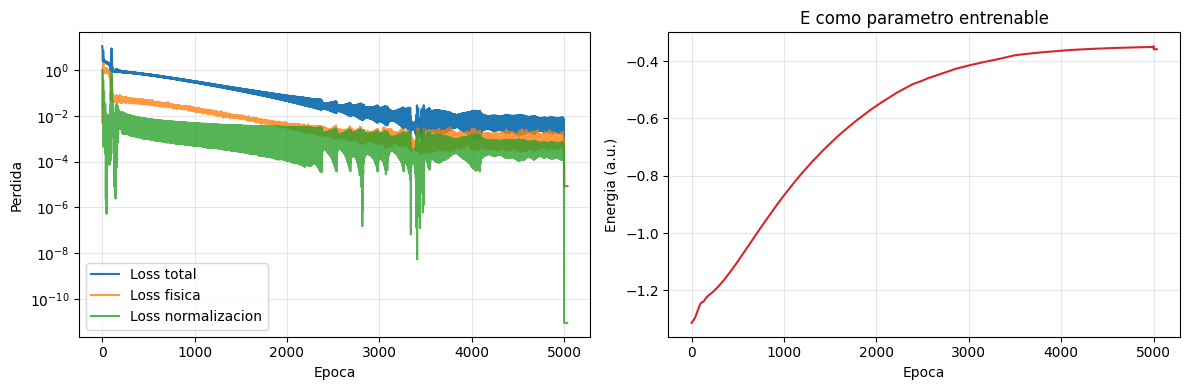

In [15]:
# Curvas de entrenamiento
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(history["total"], label="Loss total")
ax[0].plot(history["phys"], label="Loss fisica", alpha=0.8)
ax[0].plot(history["norm"], label="Loss normalizacion", alpha=0.8)
ax[0].set_yscale("log")
ax[0].set_xlabel("Epoca")
ax[0].set_ylabel("Perdida")
ax[0].grid(True, alpha=0.3)
ax[0].legend()

ax[1].plot(history["E"], color="tab:red")
ax[1].set_xlabel("Epoca")
ax[1].set_ylabel("Energia (a.u.)")
ax[1].set_title("E como parametro entrenable")
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
# Evaluacion final
with torch.no_grad():
    r_eval = torch.linspace(r_min, r_max, 1200, device=device).view(-1, 1)
    R_eval = model.wave(r_eval).cpu().numpy().squeeze()
    r_np = r_eval.cpu().numpy().squeeze()
    E_au = model.energy().item()

# Normaliza explicitamente para mostrar la forma de onda final
norm = np.trapezoid(R_eval**2, r_np)
R_eval = R_eval / np.sqrt(norm + 1e-14)
E_eV = 27.211386 * E_au

print(f"Energia final: {E_au:.6f} a.u. = {E_eV:.6f} eV")
print(f"Integral de normalizacion (post): {np.trapezoid(R_eval**2, r_np):.6f}")

Energia final: -0.358241 a.u. = -9.748222 eV
Integral de normalizacion (post): 1.000000


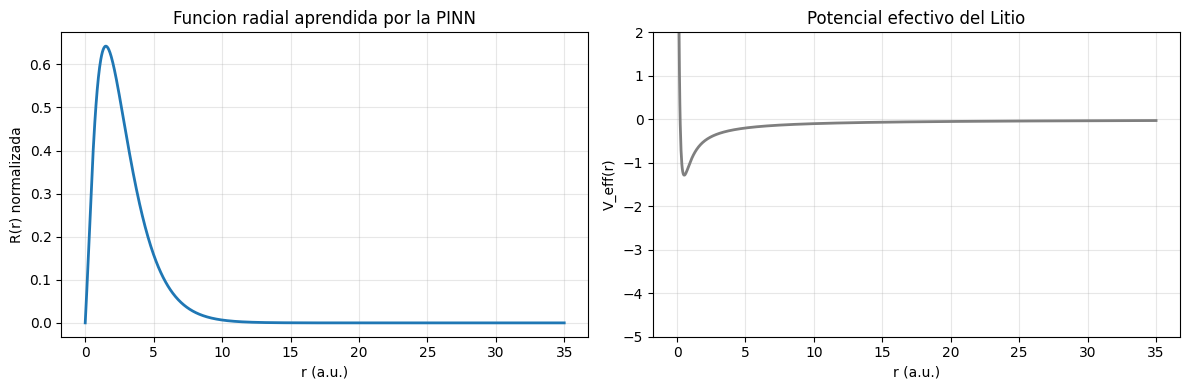

In [17]:
# Visualizacion de R(r) y potencial
V_np = (-1.0 / r_np) + (2.0 / r_np) * (1.0 + alpha * r_np) * np.exp(-2.0 * alpha * r_np) + l * (l + 1.0) / (2.0 * r_np**2)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(r_np, R_eval, color="tab:blue", lw=2)
ax[0].set_xlabel("r (a.u.)")
ax[0].set_ylabel("R(r) normalizada")
ax[0].set_title("Funcion radial aprendida por la PINN")
ax[0].grid(True, alpha=0.3)

ax[1].plot(r_np, V_np, color="tab:gray", lw=2)
ax[1].set_xlabel("r (a.u.)")
ax[1].set_ylabel("V_eff(r)")
ax[1].set_title("Potencial efectivo del Litio")
ax[1].set_ylim(-5, 2)
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Notas para extender
- Para estados excitados, agrega una restriccion de ortogonalidad con estados ya encontrados.
- Puedes barrer diferentes valores de $l$ para reconstruir parte del espectro $(nl)$.
- Si la convergencia es inestable, aumenta `n_f`, reduce `lr` o cambia `w_n`.

## Comparacion PINN vs Diferencias Finitas
En esta seccion resolvemos el mismo problema radial con un esquema de diferencias finitas (DF) sobre la misma malla de evaluacion y comparamos:
- Energia del estado ligado (a.u. y eV).
- Error relativo de energia respecto a DF.
- MSE entre funciones radiales normalizadas.
- Solapamiento cuadrado entre funciones.

In [18]:
# Solver por diferencias finitas (DF) para el mismo potencial y dominio
N = len(r_np)
h = (r_np[-1] - r_np[0]) / (N - 1)

r_int = r_np[1:-1]
V_int = (-1.0 / r_int) + (2.0 / r_int) * (1.0 + alpha * r_int) * np.exp(-2.0 * alpha * r_int) + l * (l + 1.0) / (2.0 * r_int**2)

# Hamiltoniano discreto: H = -0.5*D2 + V
n_int = len(r_int)
diag = (1.0 / h**2) + V_int
off = -0.5 / h**2 * np.ones(n_int - 1)
H = np.diag(diag) + np.diag(off, 1) + np.diag(off, -1)

evals, evecs = np.linalg.eigh(H)

# Estado fundamental ligado para el l actual
idx0 = int(np.argmin(evals))
E_df_au = float(evals[idx0])
E_df_eV = 27.211386 * E_df_au

R_df_int = evecs[:, idx0]
R_df = np.zeros_like(r_np)
R_df[1:-1] = R_df_int

# Normalizacion de la solucion DF
norm_df = np.trapezoid(R_df**2, r_np)
R_df = R_df / np.sqrt(norm_df + 1e-14)

# Alinear signo (la autofuncion puede salir con signo global opuesto)
if np.trapezoid(R_df * R_eval, r_np) < 0:
    R_df = -R_df

# Metricas de comparacion
mse_wave = float(np.mean((R_eval - R_df)**2))
overlap = float(np.trapezoid(R_eval * R_df, r_np))
overlap_sq = overlap**2
errE_rel = abs(E_eV - E_df_eV) / (abs(E_df_eV) + 1e-14)

comparison_rows = [
    ("PINN", E_au, E_eV),
    ("Dif. Finitas", E_df_au, E_df_eV),
]

print("=== Tabla de comparacion de energias ===")
print(f"{'Metodo':<15} {'E (a.u.)':>14} {'E (eV)':>14}")
for name, eau, eev in comparison_rows:
    print(f"{name:<15} {eau:>14.6f} {eev:>14.6f}")

print("\n=== Metricas PINN vs DF ===")
print(f"Error relativo de energia: {errE_rel:.3e}")
print(f"MSE funcion radial:        {mse_wave:.3e}")
print(f"Solapamiento^2:            {overlap_sq:.6f}")

=== Tabla de comparacion de energias ===
Metodo                E (a.u.)         E (eV)
PINN                 -0.358241      -9.748222
Dif. Finitas         -0.358308      -9.750063

=== Metricas PINN vs DF ===
Error relativo de energia: 1.888e-04
MSE funcion radial:        1.092e-05
Solapamiento^2:            0.999618


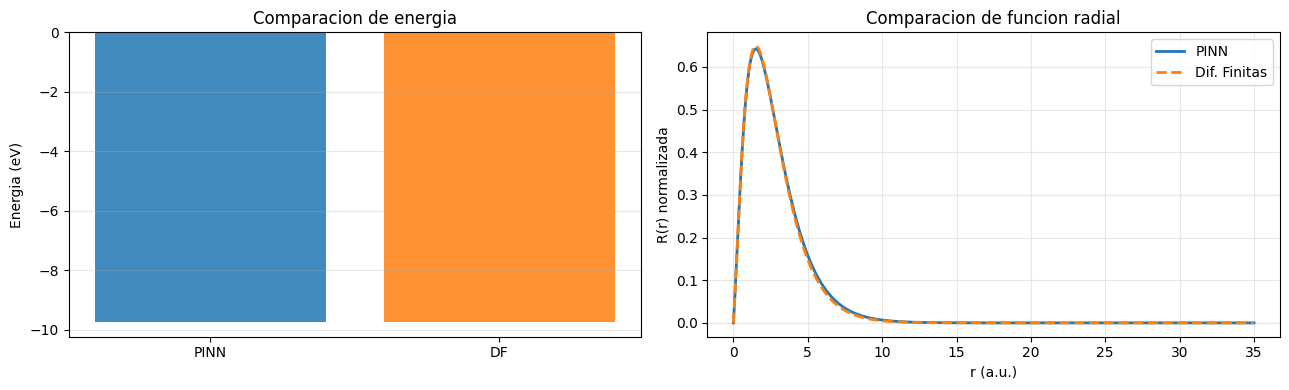

In [19]:
# Grafica comparativa: energias y funciones radiales
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

labels = ["PINN", "DF"]
energies_ev = [E_eV, E_df_eV]
ax[0].bar(labels, energies_ev, color=["tab:blue", "tab:orange"], alpha=0.85)
ax[0].set_ylabel("Energia (eV)")
ax[0].set_title("Comparacion de energia")
ax[0].grid(True, axis="y", alpha=0.3)

ax[1].plot(r_np, R_eval, label="PINN", lw=2, color="tab:blue")
ax[1].plot(r_np, R_df, label="Dif. Finitas", lw=2, ls="--", color="tab:orange")
ax[1].set_xlabel("r (a.u.)")
ax[1].set_ylabel("R(r) normalizada")
ax[1].set_title("Comparacion de funcion radial")
ax[1].grid(True, alpha=0.3)
ax[1].legend()

plt.tight_layout()
plt.show()

## PINN multestado (2s, 3s, 4s, 2p, 3p, 3d) y tabla comparativa
Esta seccion entrena una PINN por estado usando:
- Ecuacion de Schrodinger radial (sin datos etiquetados).
- Condiciones de frontera y normalizacion.
- Restriccion de ortogonalidad entre estados con el mismo $l$ ya encontrados.

Con esto se pueden graficar varios niveles y construir la tabla comparativa tipo `.tex`.

In [20]:
import time

states_tex = [
    {"label": "2s", "n": 2, "l": 0, "E_exp_eV": -5.39, "E_hyd_eV": -3.401},
    {"label": "3s", "n": 3, "l": 0, "E_exp_eV": -2.02, "E_hyd_eV": -1.512},
    {"label": "4s", "n": 4, "l": 0, "E_exp_eV": -1.05, "E_hyd_eV": -0.850},
    {"label": "2p", "n": 2, "l": 1, "E_exp_eV": -3.54, "E_hyd_eV": -3.401},
    {"label": "3p", "n": 3, "l": 1, "E_exp_eV": -1.56, "E_hyd_eV": -1.512},
    {"label": "3d", "n": 3, "l": 2, "E_exp_eV": -1.51, "E_hyd_eV": -1.512},
]

# Hiperparametros para multestado (ajustables)
ms_width = 96
ms_depth = 5
ms_adam_epochs = 1800
ms_lbfgs_steps = 120
ms_n_f = 1000

ms_w_b = 5.0
ms_w_n = 10.0
ms_w_e = 1.0
ms_w_ortho = 20.0

r_grid_ms = np.linspace(r_min, r_max, 1500).astype(np.float32)
r_grid_ms_t = torch.tensor(r_grid_ms.reshape(-1, 1), device=device)

def inv_softplus(y):
    y = max(float(y), 1e-6)
    return np.log(np.expm1(y))

def v_eff_state(r, l_state, alpha=alpha):
    coulomb_screened = -1.0 / r + (2.0 / r) * (1.0 + alpha * r) * torch.exp(-2.0 * alpha * r)
    centrifugal = l_state * (l_state + 1.0) / (2.0 * r**2)
    return coulomb_screened + centrifugal

class PINNWaveState(nn.Module):
    def __init__(self, l_state, n_nodes, width=96, depth=5, e_init_au=-0.2):
        super().__init__()
        self.l_state = l_state
        self.n_nodes = n_nodes

        layers = [nn.Linear(1, width), nn.Tanh()]
        for _ in range(depth - 1):
            layers.extend([nn.Linear(width, width), nn.Tanh()])
        layers.append(nn.Linear(width, 1))
        self.net = nn.Sequential(*layers)

        self.energy_raw = nn.Parameter(torch.tensor([inv_softplus(-e_init_au)], dtype=torch.float32))
        self.decay_raw = nn.Parameter(torch.tensor([0.7], dtype=torch.float32))

        if n_nodes > 0:
            # Nodos fijos en coordenada escalada x in [0,1]
            node_pos = torch.linspace(0.15, 0.85, n_nodes).view(1, -1)
            self.register_buffer("node_pos", node_pos)
        else:
            self.register_buffer("node_pos", torch.empty((1, 0)))

    def energy(self):
        return -torch.nn.functional.softplus(self.energy_raw)

    def decay(self):
        return torch.nn.functional.softplus(self.decay_raw) + 1e-3

    def raw(self, r):
        x = 2.0 * (r - r_min) / (r_max - r_min) - 1.0
        return self.net(x)

    def wave(self, r):
        k = self.decay()
        base = (r ** (self.l_state + 1.0)) * torch.exp(-k * r)

        if self.n_nodes > 0:
            x = (r - r_min) / (r_max - r_min)
            node_factor = torch.prod(x - self.node_pos, dim=1, keepdim=True)
        else:
            node_factor = torch.ones_like(r)

        return base * node_factor * self.raw(r)

def sample_r_ms(n_points):
    u = torch.rand((n_points, 1), device=device)
    r = r_min + (r_max - r_min) * (u**2)
    r.requires_grad_(True)
    return r

def second_derivative_ms(y, x):
    dy = torch.autograd.grad(y, x, grad_outputs=torch.ones_like(y), create_graph=True)[0]
    ddy = torch.autograd.grad(dy, x, grad_outputs=torch.ones_like(dy), create_graph=True)[0]
    return ddy

def losses_state(model, r_f, orth_refs):
    R = model.wave(r_f)
    R_r = torch.autograd.grad(R, r_f, grad_outputs=torch.ones_like(R), create_graph=True)[0]
    R_rr = second_derivative_ms(R, r_f)
    E = model.energy()
    V = v_eff_state(r_f, model.l_state)

    residual = -0.5 * R_rr + V * R - E * R
    loss_phys = torch.mean(residual**2)

    r0_t = torch.tensor([[r_min]], dtype=torch.float32, device=device)
    rR_t = torch.tensor([[r_max]], dtype=torch.float32, device=device)
    loss_bc = model.wave(r0_t).pow(2).mean() + model.wave(rR_t).pow(2).mean()

    idx = torch.argsort(r_f.squeeze())
    rs = r_f.squeeze()[idx]
    R_s = R.squeeze()[idx]
    Rr_s = R_r.squeeze()[idx]
    V_s = V.squeeze()[idx]

    norm_int = torch.trapz(R_s**2, rs)
    loss_norm = (norm_int - 1.0)**2

    kinetic = 0.5 * torch.trapz(Rr_s**2, rs)
    potential = torch.trapz(V_s * R_s**2, rs)
    E_rayleigh = (kinetic + potential) / (norm_int + 1e-12)
    loss_energy = (E - E_rayleigh)**2

    # Ortogonalidad con estados previos del mismo l
    loss_ortho = torch.tensor(0.0, device=device)
    if orth_refs:
        with torch.no_grad():
            pass
        r_ref = torch.tensor(r_grid_ms.reshape(-1, 1), dtype=torch.float32, device=device)
        R_ref = model.wave(r_ref).squeeze()
        for R_prev_np in orth_refs:
            R_prev = torch.tensor(R_prev_np, dtype=torch.float32, device=device)
            ov = torch.trapz(R_ref * R_prev, r_ref.squeeze())
            loss_ortho = loss_ortho + ov**2

    loss_total = loss_phys + ms_w_b * loss_bc + ms_w_n * loss_norm + ms_w_e * loss_energy + ms_w_ortho * loss_ortho
    return loss_total, loss_phys, loss_bc, loss_norm, loss_energy, loss_ortho, E.detach()

In [ ]:
def train_state_pinn(state, orth_by_l):
    label = state["label"]
    n = state["n"]
    l_state = state["l"]
    n_nodes = max(n - l_state - 1, 0)

    # Inicializacion energetica cerca de exp para acelerar convergencia
    e_init_au = state["E_exp_eV"] / 27.211386

    model_s = PINNWaveState(
        l_state=l_state,
        n_nodes=n_nodes,
        width=ms_width,
        depth=ms_depth,
        e_init_au=e_init_au
    ).to(device)

    opt_adam = torch.optim.Adam(model_s.parameters(), lr=1e-3)
    opt_lbfgs = torch.optim.LBFGS(
        model_s.parameters(),
        lr=0.8,
        max_iter=20,
        history_size=50,
        line_search_fn="strong_wolfe"
    )

    orth_refs = orth_by_l.get(l_state, [])

    # Adam
    for _ in range(ms_adam_epochs):
        opt_adam.zero_grad()
        r_batch = sample_r_ms(ms_n_f)
        lt, lp, lb, ln, le, lo, _ = losses_state(model_s, r_batch, orth_refs)
        lt.backward()
        torch.nn.utils.clip_grad_norm_(model_s.parameters(), max_norm=1.0)
        opt_adam.step()

    # LBFGS
    r_lb = sample_r_ms(2 * ms_n_f)
    for _ in range(ms_lbfgs_steps):
        def closure():
            opt_lbfgs.zero_grad()
            ltot, *_ = losses_state(model_s, r_lb, orth_refs)
            ltot.backward()
            return ltot
        opt_lbfgs.step(closure)

    # Evaluacion
    with torch.no_grad():
        R_np = model_s.wave(r_grid_ms_t).cpu().numpy().squeeze()
        E_au = float(model_s.energy().item())

    norm = np.trapezoid(R_np**2, r_grid_ms)
    R_np = R_np / np.sqrt(norm + 1e-14)

    # Signo consistente con primer estado del mismo l
    if orth_refs:
        ov = np.trapezoid(R_np * orth_refs[0], r_grid_ms)
        if ov < 0:
            R_np = -R_np

    result = {
        "label": label,
        "n": n,
        "l": l_state,
        "E_pinn_au": E_au,
        "E_pinn_eV": 27.211386 * E_au,
        "R": R_np,
    }
    return result

# Entrenar todos los niveles pedidos en la tabla del .tex
start = time.time()
orth_by_l = {0: [], 1: [], 2: []}
results_ms = []

for st in states_tex:
    print(f"Entrenando estado {st['label']} ...")
    res = train_state_pinn(st, orth_by_l)
    results_ms.append(res)
    orth_by_l[st["l"]].append(res["R"])
    print(f"  -> E_PINN = {res['E_pinn_eV']:.4f} eV")

elapsed = time.time() - start
print(f"Tiempo total multestado: {elapsed:.1f} s")

Entrenando estado 2s ...
  -> E_PINN = -9.2987 eV
Entrenando estado 3s ...
  -> E_PINN = -1.5324 eV
Entrenando estado 4s ...
  -> E_PINN = -0.0000 eV
Entrenando estado 2p ...
  -> E_PINN = -3.3396 eV
Entrenando estado 3p ...
  -> E_PINN = -0.0000 eV
Entrenando estado 3d ...


In [ ]:
# Tabla comparativa en formato similar al .tex
rows = []
for st in states_tex:
    rr = next(x for x in results_ms if x["label"] == st["label"])
    rows.append({
        "nl": st["label"],
        "E_PINN (eV)": rr["E_pinn_eV"],
        "E_Exp (eV)": st["E_exp_eV"],
        "At. Hidr. (eV)": st["E_hyd_eV"],
        "Error rel PINN-Exp": abs(rr["E_pinn_eV"] - st["E_exp_eV"]) / (abs(st["E_exp_eV"]) + 1e-12)
    })

print("=== Tabla comparativa de niveles (PINN vs Exp vs H) ===")
print(f"{'(nl)':<6} {'E_PINN':>12} {'E_Exp':>12} {'At.Hidr.':>12} {'ErrRel':>12}")
for r in rows:
    print(f"{r['nl']:<6} {r['E_PINN (eV)']:>12.4f} {r['E_Exp (eV)']:>12.4f} {r['At. Hidr. (eV)']:>12.4f} {r['Error rel PINN-Exp']:>12.4e}")

# Grafica de niveles de energia
labels = [r["nl"] for r in rows]
E_pinn = [r["E_PINN (eV)"] for r in rows]
E_exp = [r["E_Exp (eV)"] for r in rows]
E_hyd = [r["At. Hidr. (eV)"] for r in rows]

x = np.arange(len(labels))
w = 0.25

plt.figure(figsize=(12, 4.8))
plt.bar(x - w, E_pinn, width=w, label="PINN", color="tab:blue")
plt.bar(x, E_exp, width=w, label="Experimental", color="tab:orange")
plt.bar(x + w, E_hyd, width=w, label="Atomo H", color="tab:green")
plt.xticks(x, labels)
plt.ylabel("Energia (eV)")
plt.title("Comparacion de niveles de energia del Litio")
plt.grid(True, axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()